# Notebook 0.5 — How should we *edit* a real photo?

**Workshop path:** run [Notebook 0](00_flight_precheck.ipynb) first · recommended `HARDWARE` from that notebook · production path later is **`instruct` (Klein) + API judge** in [Notebook 1](01_sample_data_generation.ipynb).

This notebook is mostly **teaching**. You will compare several ways to insert a rare edge-case into a real street photo, then pick a default generator for the rest of the workshop.

### What you should leave with

1. A mental model of the main **image-edit** families (mask inpaint → structure ControlNet → instruction editors → cloud image models).
2. Clear intuition for **inputs**, **where each shines**, and **how each fails**.
3. A justified choice for Notebook 1/2 (usually Klein `instruct` on L4).

Judging, fidelity/novelty gates, and training value come in Notebook 1–3 — here we focus on **generation methods in isolation**.


---
## Why edit real photos at all?

Rare events (a cone in an odd place, debris on the lane, sudden fog) are exactly what break perception models — and exactly what you rarely have labeled photos of. Training only on common scenes leaves a **long tail** of failure modes.

One practical response: start from **real** camera photos (correct optics, lighting, clutter) and **edit** them so the rare condition appears, instead of synthesizing entire cities from text. That bias toward real geometry is why this bootcamp prefers edit/instruct pipelines over pure text-to-image for ADAS-style data.

> **Not the same as the judge.** Chat VLMs (Gemini Flash, GPT-4o) *describe* images. **Image** models (`gemini-*-image`, Klein, Qwen-Image-Edit) *emit pixels*. Notebook 1 uses an API VLM as **judge**; this notebook compares **pixel editors**.


---
## A short history of the methods you will run

| Era | Idea | What changed |
|-----|------|----------------|
| Classical / early deep inpaint | Fill a **masked hole** from surrounding context | Strong localization if the mask is good; brittle seams and mask engineering |
| Latent diffusion + inpaint [[1]](../docs/citations.md) | Same hole-filling, but in a learned latent space (SD / FLUX inpaint) | Higher fidelity fills; still needs a mask |
| ControlNet [[2]](../docs/citations.md) | Extra encoders lock **structure** (depth, edges, seg) while the prompt changes appearance | Can edit *without* a hole — but may rewrite the whole frame |
| InstructPix2Pix [[3]](../docs/citations.md) → modern instruct editors | Edit from an **English instruction** + the photo (no mask) | Easy UX; weaker spatial guarantees (“put it *there*”) |
| Large / cloud image editors [[4]](../docs/citations.md)[[5]](../docs/citations.md) | Bigger local models (Qwen-Image-Edit) or cloud image APIs (Nano Banana 2) | Strong semantics; risk of drifting away from the seed photo |

The columns below are not “better → worse”. They trade **spatial control**, **scene preservation**, and **setup cost**.


---
## Method cards

### 1. Inpaint + mask

**Idea.** Paint a binary hole where the rare object should appear; a diffusion inpaint model fills only that region (optionally recomposited).

| | |
|--|--|
| **Inputs** | RGB seed · binary mask · text prompt · (here) road∩near-depth prior for the mask |
| **Shines** | Local inserts (cone, cardboard on asphalt); preserves most of the real photo outside the hole |
| **Fails** | Bad masks → floating objects or rectangle seams; global weather (fog) is the wrong tool |
| **Bootcamp role** | Strong baseline when you can afford mask logic |

### 2. ControlNet depth + segmentation (no mask)

**Idea.** Condition generation on **structure maps** so layout stays plausible while the prompt requests a change [[2]](../docs/citations.md).

| | |
|--|--|
| **Inputs** | RGB · depth map · seg (or Canny-on-seg) · prompt |
| **Shines** | Global or mid-scale changes that should respect geometry (fog-ish atmosphere, layout-aware edits) |
| **Fails** | Can still rewrite identity of cars/sky; heavier conditioning stack; slower |
| **Bootcamp role** | Contrast to mask/instruct — “structure without a hole” |

### 3. Instruction edit — Klein / InstructPix2Pix (**default later**)

**Idea.** One photo + one instruction (“add an orange traffic cone on the right lane”). No mask. IP2P taught this pattern [[3]](../docs/citations.md); on L4 we use a small **FLUX.2-klein** instruct checkpoint [[4]](../docs/citations.md).

| | |
|--|--|
| **Inputs** | RGB · text instruction only |
| **Shines** | Fast iteration; no mask authoring; good enough local inserts for workshop scale |
| **Fails** | Weak placement control; may paste on the ego hood; may ignore the ask or restyle the frame |
| **Bootcamp role** | **Production generator for NB1/NB2** after you see the bake-off |

### 4. Large local VLM editor — Qwen-Image-Edit *(optional)*

**Idea.** Same *role* as Klein (instruction edit), but a much larger local model [[5]](../docs/citations.md).

| | |
|--|--|
| **Inputs** | RGB · instruction |
| **Shines** | Potentially stronger instruction following / semantics when you have the hardware |
| **Fails** | Tens of GB download + multi-GPU VRAM; overkill for the workshop default |
| **Bootcamp role** | Opt-in comparison column only (`INCLUDE_QWEN_LOCAL=True`) |

### 5. Cloud image model — Nano Banana 2 *(optional)*

**Idea.** Call an **image-capable** model (`gemini-3.1-flash-image`) through the **same Vector proxy** as the judge (`OPENAI_API_KEY` / `vp_…`).

| | |
|--|--|
| **Inputs** | Seed photo + edit instruction (or text-only generate) |
| **Shines** | Strong world knowledge; zero local GPU for the edit itself |
| **Fails** | May rewrite the scene; depends on proxy/model availability; not the offline path |
| **Bootcamp role** | Optional cloud column — **not** a substitute for the API **judge** in NB1 |


---
## 0. Setup

Prefer [Notebook 0](00_flight_precheck.ipynb) for env + data. If you are jumping in cold:

```bash
# From repo root
uv sync --dev --group edge-case-image-generation
# Optional .env only for your own API overrides / HF_TOKEN — Vector baseline is usually already in the workshop env
cp implementations/edge_case_image_generation/.env.example \
   implementations/edge_case_image_generation/.env
```

Select the project kernel, then run the next cell.


In [1]:
from pathlib import Path

from aieng.syn_data.image.bootstrap import bootstrap_project_root
from aieng.syn_data.image.config import load_env


PROJECT_ROOT = bootstrap_project_root()
load_env(PROJECT_ROOT)
print("PROJECT_ROOT =", PROJECT_ROOT)

/home/coder/synthetic-data-bootcamp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT = /home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation


---
## 1. Knobs + clean scene seeds

Copy `HARDWARE` from Notebook 0 when you can (`gpu_l4` / `gpu_l4x2` for Klein; `cpu` is slow but fine for reading outputs).

| Knob | Meaning |
|------|---------|
| `INCLUDE_QWEN_LOCAL` | Add Qwen-Image-Edit column (heavy) |
| `INCLUDE_VLM_API` | Add Nano Banana 2 via Vector proxy |
| `VLM_API_MODEL` | Image model id on the proxy (default Nano Banana 2) |

We edit **empty** `scene_*` frames — one workshop anomaly each.


/home/coder/synthetic-data-bootcamp/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


DataSourceInfo(name='mapillary_vistas', label='Mapillary Vistas v2 (toy street subset)', license='CC BY-NC-SA 4.0', attribution='Mapillary Vistas Dataset v2.0 (Neuhold et al.). HF mirror: https://huggingface.co/datasets/candylion/mapillary-vistas-v2')
HARDWARE=gpu_l4x2  instruct=black-forest-labs/FLUX.2-klein-4B
Active methods (4): ('controlnet_dual', 'inpaint', 'instruct', 'vlm_generate_api')
  scene_-_prubhCd03M0BLOHOGGOA  →  road_debris
  scene_-jGzo9blhVkb-GgmTnYzHg  →  traffic_cone
  scene_-tpmjcVylShgHq6uKICQhQ  →  trash_bin
  scene_-zwvMY-T6zh0_dZf9GW_wA  →  fog


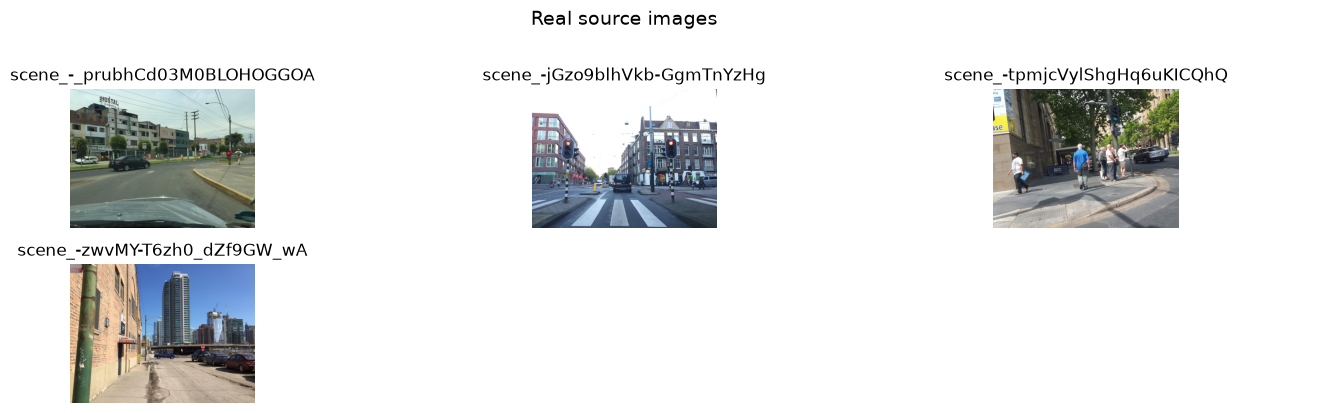

In [2]:
import os


os.environ.setdefault("HF_HUB_DISABLE_XET", "1")

from aieng.syn_data.image.compare_methods import COMPARE_METHODS
from aieng.syn_data.image.config import load_anomaly, load_config
from aieng.syn_data.image.data import (
    ImageSample,
    get_data_source_info,
    list_sample_images,
    prepare_sample_images,
)
from aieng.syn_data.image.viz import show_samples
from PIL import Image


DATASET = "mapillary_vistas"
HARDWARE = "gpu_l4x2"  # from NB0: "cpu" | "gpu_l4" | "gpu_l4x2"

INCLUDE_QWEN_LOCAL = False
INCLUDE_VLM_API = True
VLM_API_MODEL = "gemini-3.1-flash-image"  # Nano Banana 2
VLM_MODE = "edit"

cfg = load_config(
    start=PROJECT_ROOT,
    overrides=[f"dataset_name={DATASET}", f"hardware={HARDWARE}"],
)
cfg.generation.vlm_api_model = VLM_API_MODEL
cfg.generation.vlm_mode = VLM_MODE

if INCLUDE_VLM_API:
    cfg.generation.vlm_api_enabled = True
    cfg.generation.vlm_provider = "vector_proxy"
    cfg.generation.vlm_api_base_url = (
        cfg.generation.get("vlm_api_base_url")
        or os.environ.get("VECTOR_PROXY_BASE_URL")
        or "https://proxy.vectorinstitute.ai/v1"
    )
    if not (os.environ.get("OPENAI_API_KEY") or os.environ.get("VECTOR_PROXY_API_KEY")):
        print("No Vector key — disabling Nano Banana 2 column.")
        INCLUDE_VLM_API = False
        cfg.generation.vlm_api_enabled = False

ACTIVE_METHODS = tuple(
    m
    for m in COMPARE_METHODS
    if (INCLUDE_QWEN_LOCAL or m != "vlm_generate_local") and (INCLUDE_VLM_API or m != "vlm_generate_api")
)

print(get_data_source_info(cfg))
print(f"HARDWARE={HARDWARE}  instruct={cfg.generation.instruct_model_id}")
print(f"Active methods ({len(ACTIVE_METHODS)}):", ACTIVE_METHODS)

prepare_sample_images(cfg=cfg)
samples_dir = Path(cfg.paths.samples_dir)
ANOMALIES = list(cfg.dataset.workshop_anomalies)
scene_paths = sorted(p for p in list_sample_images(samples_dir) if p.stem.startswith("scene_"))
if len(scene_paths) < len(ANOMALIES):
    raise RuntimeError(
        f"Need ≥{len(ANOMALIES)} scene_* images (found {len(scene_paths)}). "
        "Re-run Notebook 0 data cell or scripts/extract_mapillary_toy.py",
    )

jobs = [
    (
        ImageSample(path=path, image=Image.open(path).convert("RGB"), name=path.stem),
        anomaly_id,
    )
    for path, anomaly_id in zip(scene_paths[: len(ANOMALIES)], ANOMALIES)
]
samples = [s for s, _ in jobs]
show_samples(samples, ncol=3, figsize=(14, 4))
for s, a in jobs:
    print(f"  {s.name}  →  {a}")

---
## 2. Structure maps (inpaint + ControlNet only)

Depth and segmentation are **conditions**, not the edit itself.

**What they do (in one breath):**
- A **depth** model looks at a single RGB photo and estimates a dense near/far map (relative depth) — no stereo pair. We use it so ControlNet can keep layout, and so the inpaint mask can prefer near asphalt.
- A **segmentation** model assigns every pixel a semantic class (here ADE20K). We treat class **6 = road** as the ground/drivable prior for edit masks and as a structure cue for ControlNet-seg.

**Checkpoints (from `configs/default/conditioning.yaml`):**
- Depth: `depth-anything/Depth-Anything-V2-Base-hf`
- Seg: `nvidia/segformer-b2-finetuned-ade-512-512`
- Ground class ids: `[6]` (ADE20K road) — add more ids there if you want sidewalk/parking in the mask prior.

**Instruct / VLM columns ignore these maps** — that is part of the point of the bake-off.


Loading weights: 100%|██████████| 503/503 [00:00<00:00, 1561.93it/s]


depth: depth-anything/Depth-Anything-V2-Large-hf | seg: nvidia/segformer-b3-finetuned-ade-512-512


Loading weights: 100%|██████████| 644/644 [00:00<00:00, 24372.95it/s]


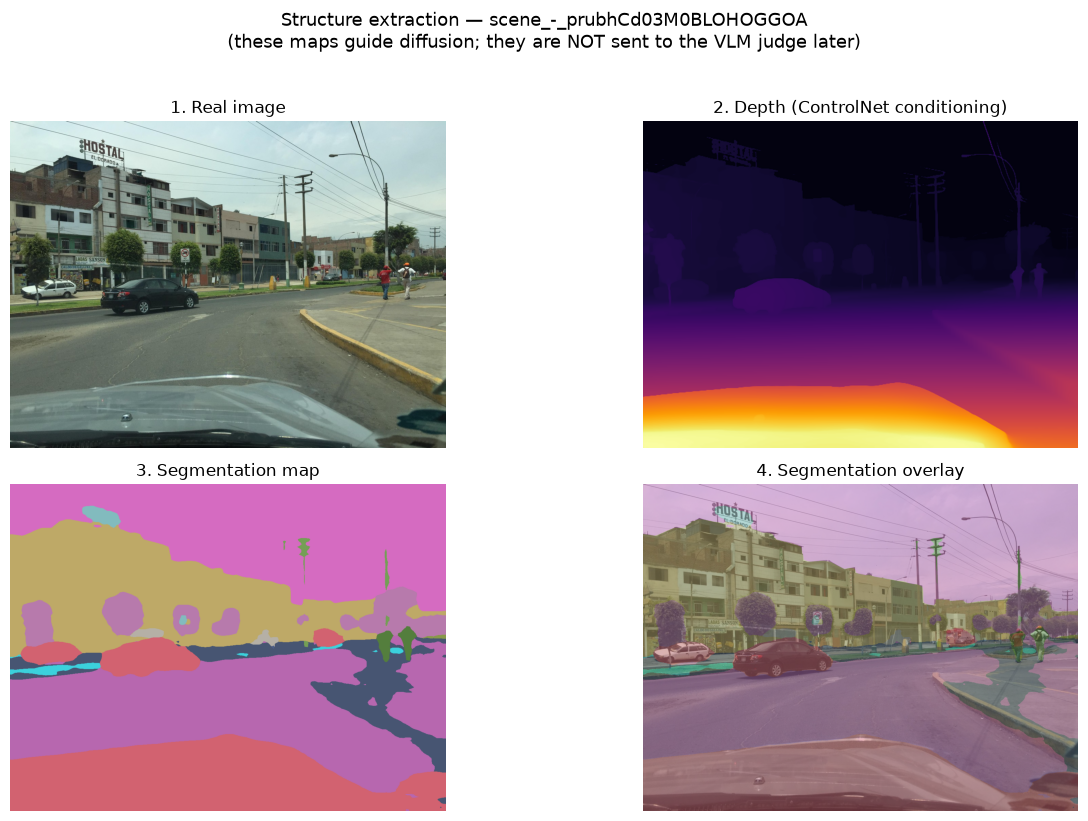

In [3]:
from aieng.syn_data.image.conditioning import DepthEstimator, Segmenter
from aieng.syn_data.image.viz import show_structure_overview


depth_model = DepthEstimator.from_config(cfg)
segmenter = Segmenter.from_config(cfg)
print("depth:", depth_model.model_id, "| seg:", segmenter.model_name)

depth_results = {s.name: depth_model.predict(s.image) for s in samples}
seg_results = {s.name: segmenter.predict(s.image) for s in samples}
show_structure_overview(samples[0], depth_results[samples[0].name], seg_results[samples[0].name]);

---
## 3. Confirm which columns will run

Quick checklist against the method cards above (mask / depth / seg flags).


In [ ]:
from aieng.syn_data.image.compare_methods import METHOD_SPECS


for key in ACTIVE_METHODS:
    spec = METHOD_SPECS[key]
    print(f"{spec.title:40s}  mask={spec.uses_mask}  depth={spec.uses_depth}  seg={spec.uses_seg}")

ControlNet (depth + seg)                  mask=False  depth=True  seg=True
Inpaint + mask                            mask=True  depth=True  seg=True
Klein instruct (small local)              mask=False  depth=False  seg=False
Nano Banana 2 (Vector proxy image API)    mask=False  depth=False  seg=False


---
## 4. Run the bake-off
> **Runtime ~5mins on `gpu_l4x2`:** 

One row per seed: original vs each active method. Failures (OOM, missing key) become a red **skipped** tile instead of crashing the notebook.

On CPU this is slow — use `HARDWARE="gpu_l4"` or `HARDWARE="gpu_l4x2"` for a real Klein column.



### scene_-_prubhCd03M0BLOHOGGOA / road_debris
  → controlnet_dual …


/home/coder/synthetic-data-bootcamp/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/home/coder/synthetic-data-bootcamp/.venv/lib/python3.12/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...: 100%|██████████| 6/6 [00:14<00:00,  2.45s/it]
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet_img2img.StableDiffusionControlNetImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the publ

  → inpaint …


100%|██████████| 4/4 [00:32<00:00,  8.24s/it]


  → instruct …


...

  → inpaint …


100%|██████████| 3/3 [00:07<00:00,  2.47s/it]


  → instruct …


100%|██████████| 4/4 [00:08<00:00,  2.22s/it]


  → vlm_generate_api …
saved → /home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/compare/scene_-zwvMY-T6zh0_dZf9GW_wA_fog


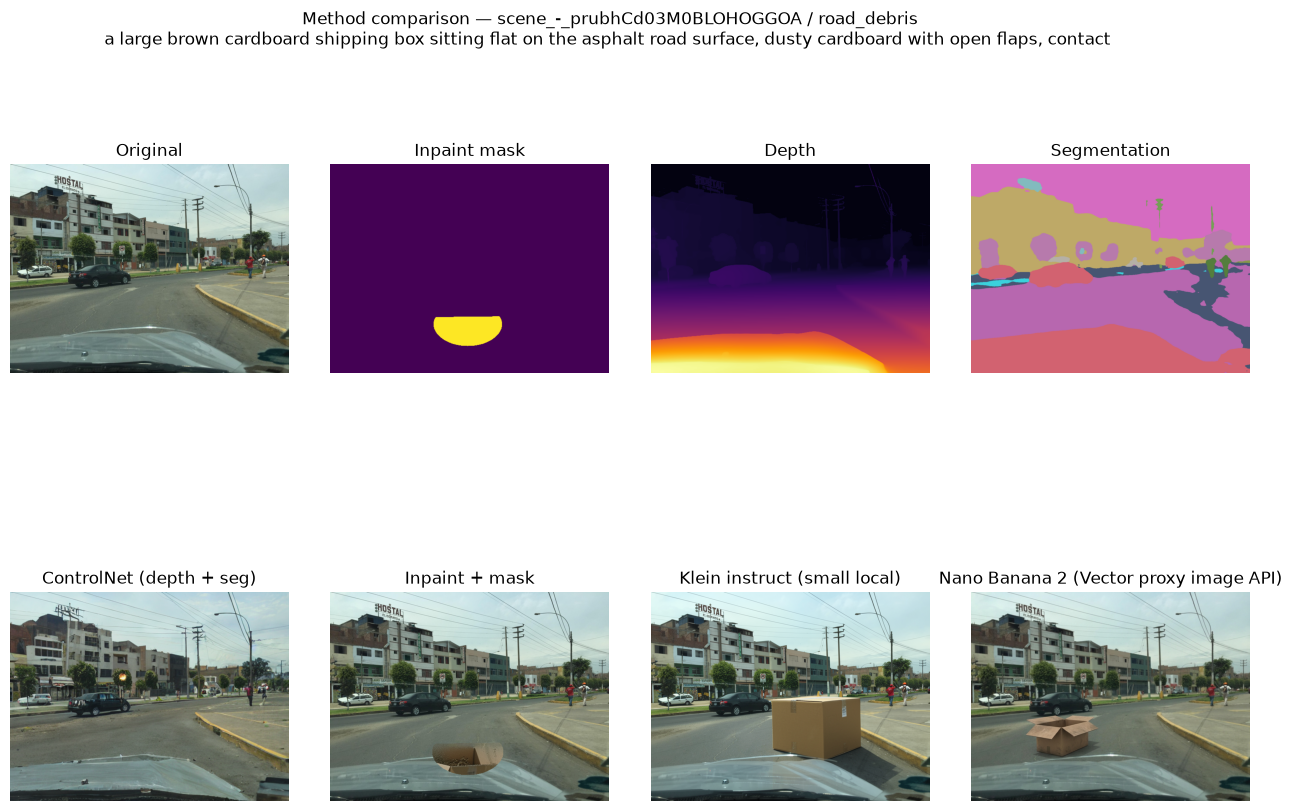

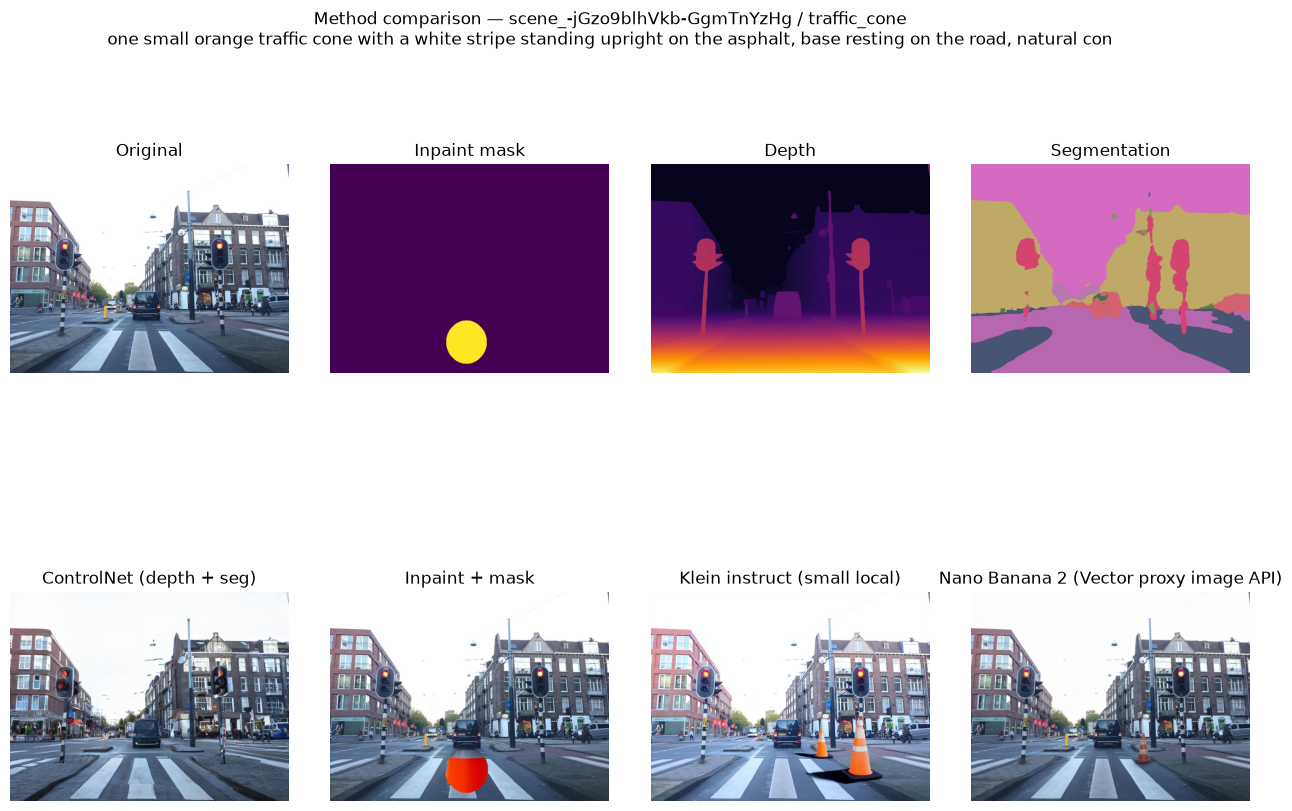

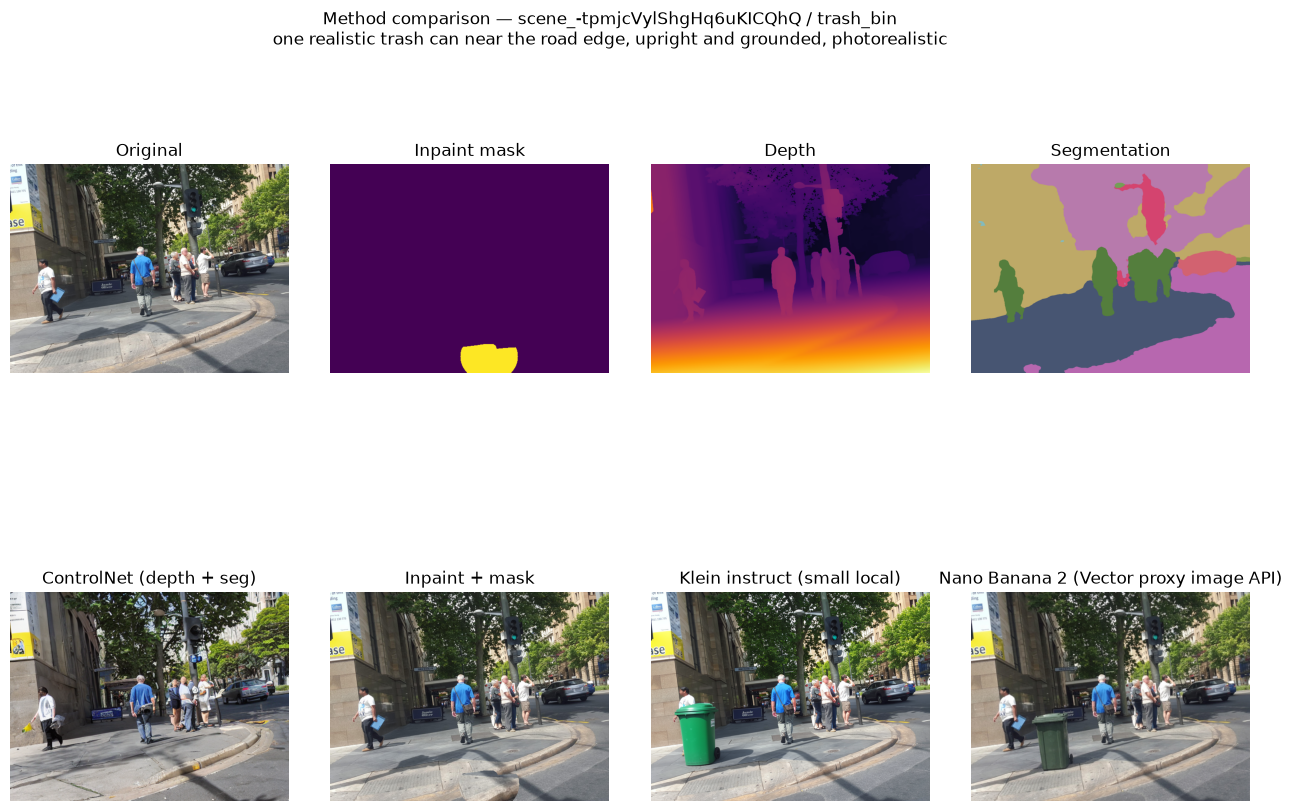

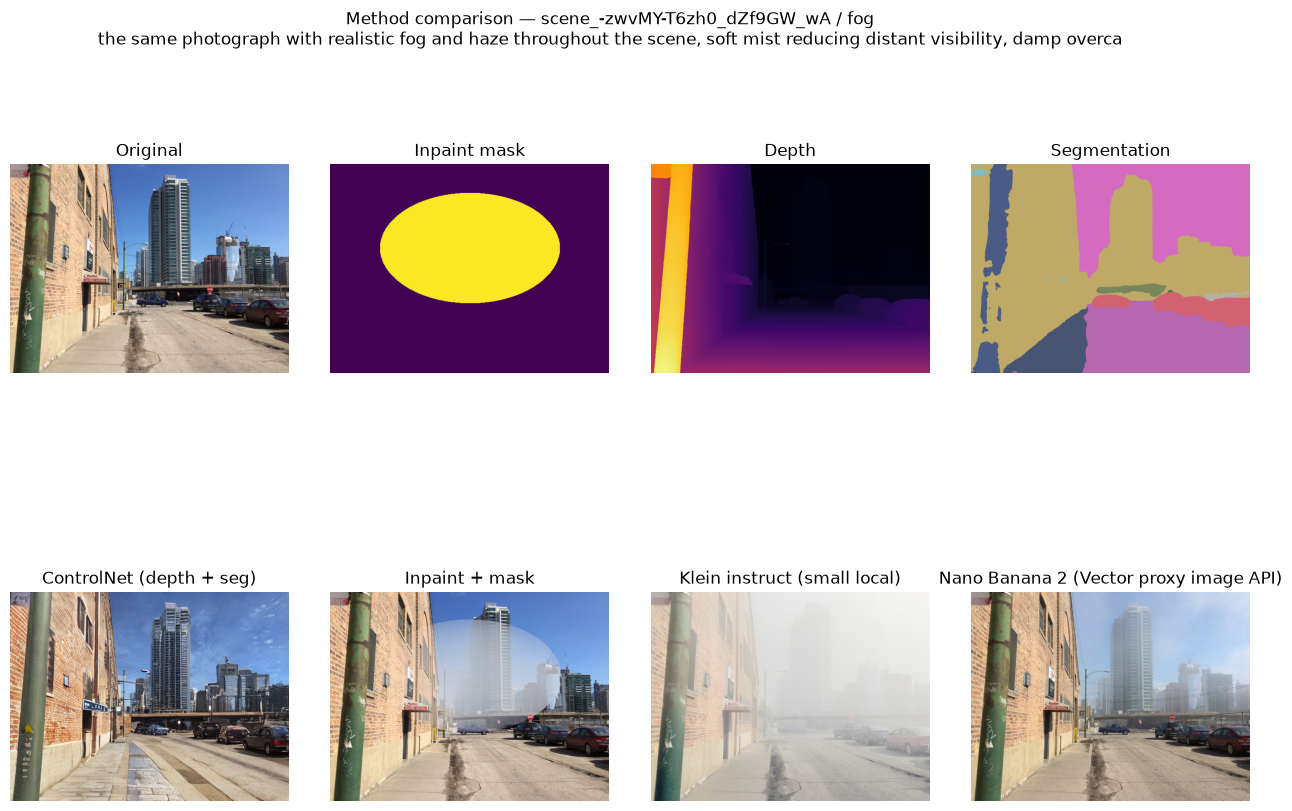

In [5]:
from aieng.syn_data.image.compare_methods import MethodComparer
from aieng.syn_data.image.viz import save_compare_artifacts, show_method_comparison


comparer = MethodComparer.from_config(cfg)
dataset = str(cfg.dataset_name)
bundles = []
output_dir = Path(cfg.paths.outputs_dir)

for sample, anomaly_id in jobs:
    print(f"\n### {sample.name} / {anomaly_id}")
    anomaly_cfg = load_anomaly(dataset, anomaly_id, start=PROJECT_ROOT)
    bundle = comparer.compare_one(
        sample.image,
        sample_name=sample.name,
        depth=depth_results[sample.name],
        segmentation=seg_results[sample.name],
        methods=ACTIVE_METHODS,
        generation_cfg=cfg.generation,
        anomaly_cfg=anomaly_cfg,
    )
    bundles.append((sample, bundle))
    show_method_comparison(sample, bundle, methods=ACTIVE_METHODS)
    paths = save_compare_artifacts(sample, bundle, output_dir)
    print("saved →", paths["dir"])

---
## 5. Side-by-side summary grid


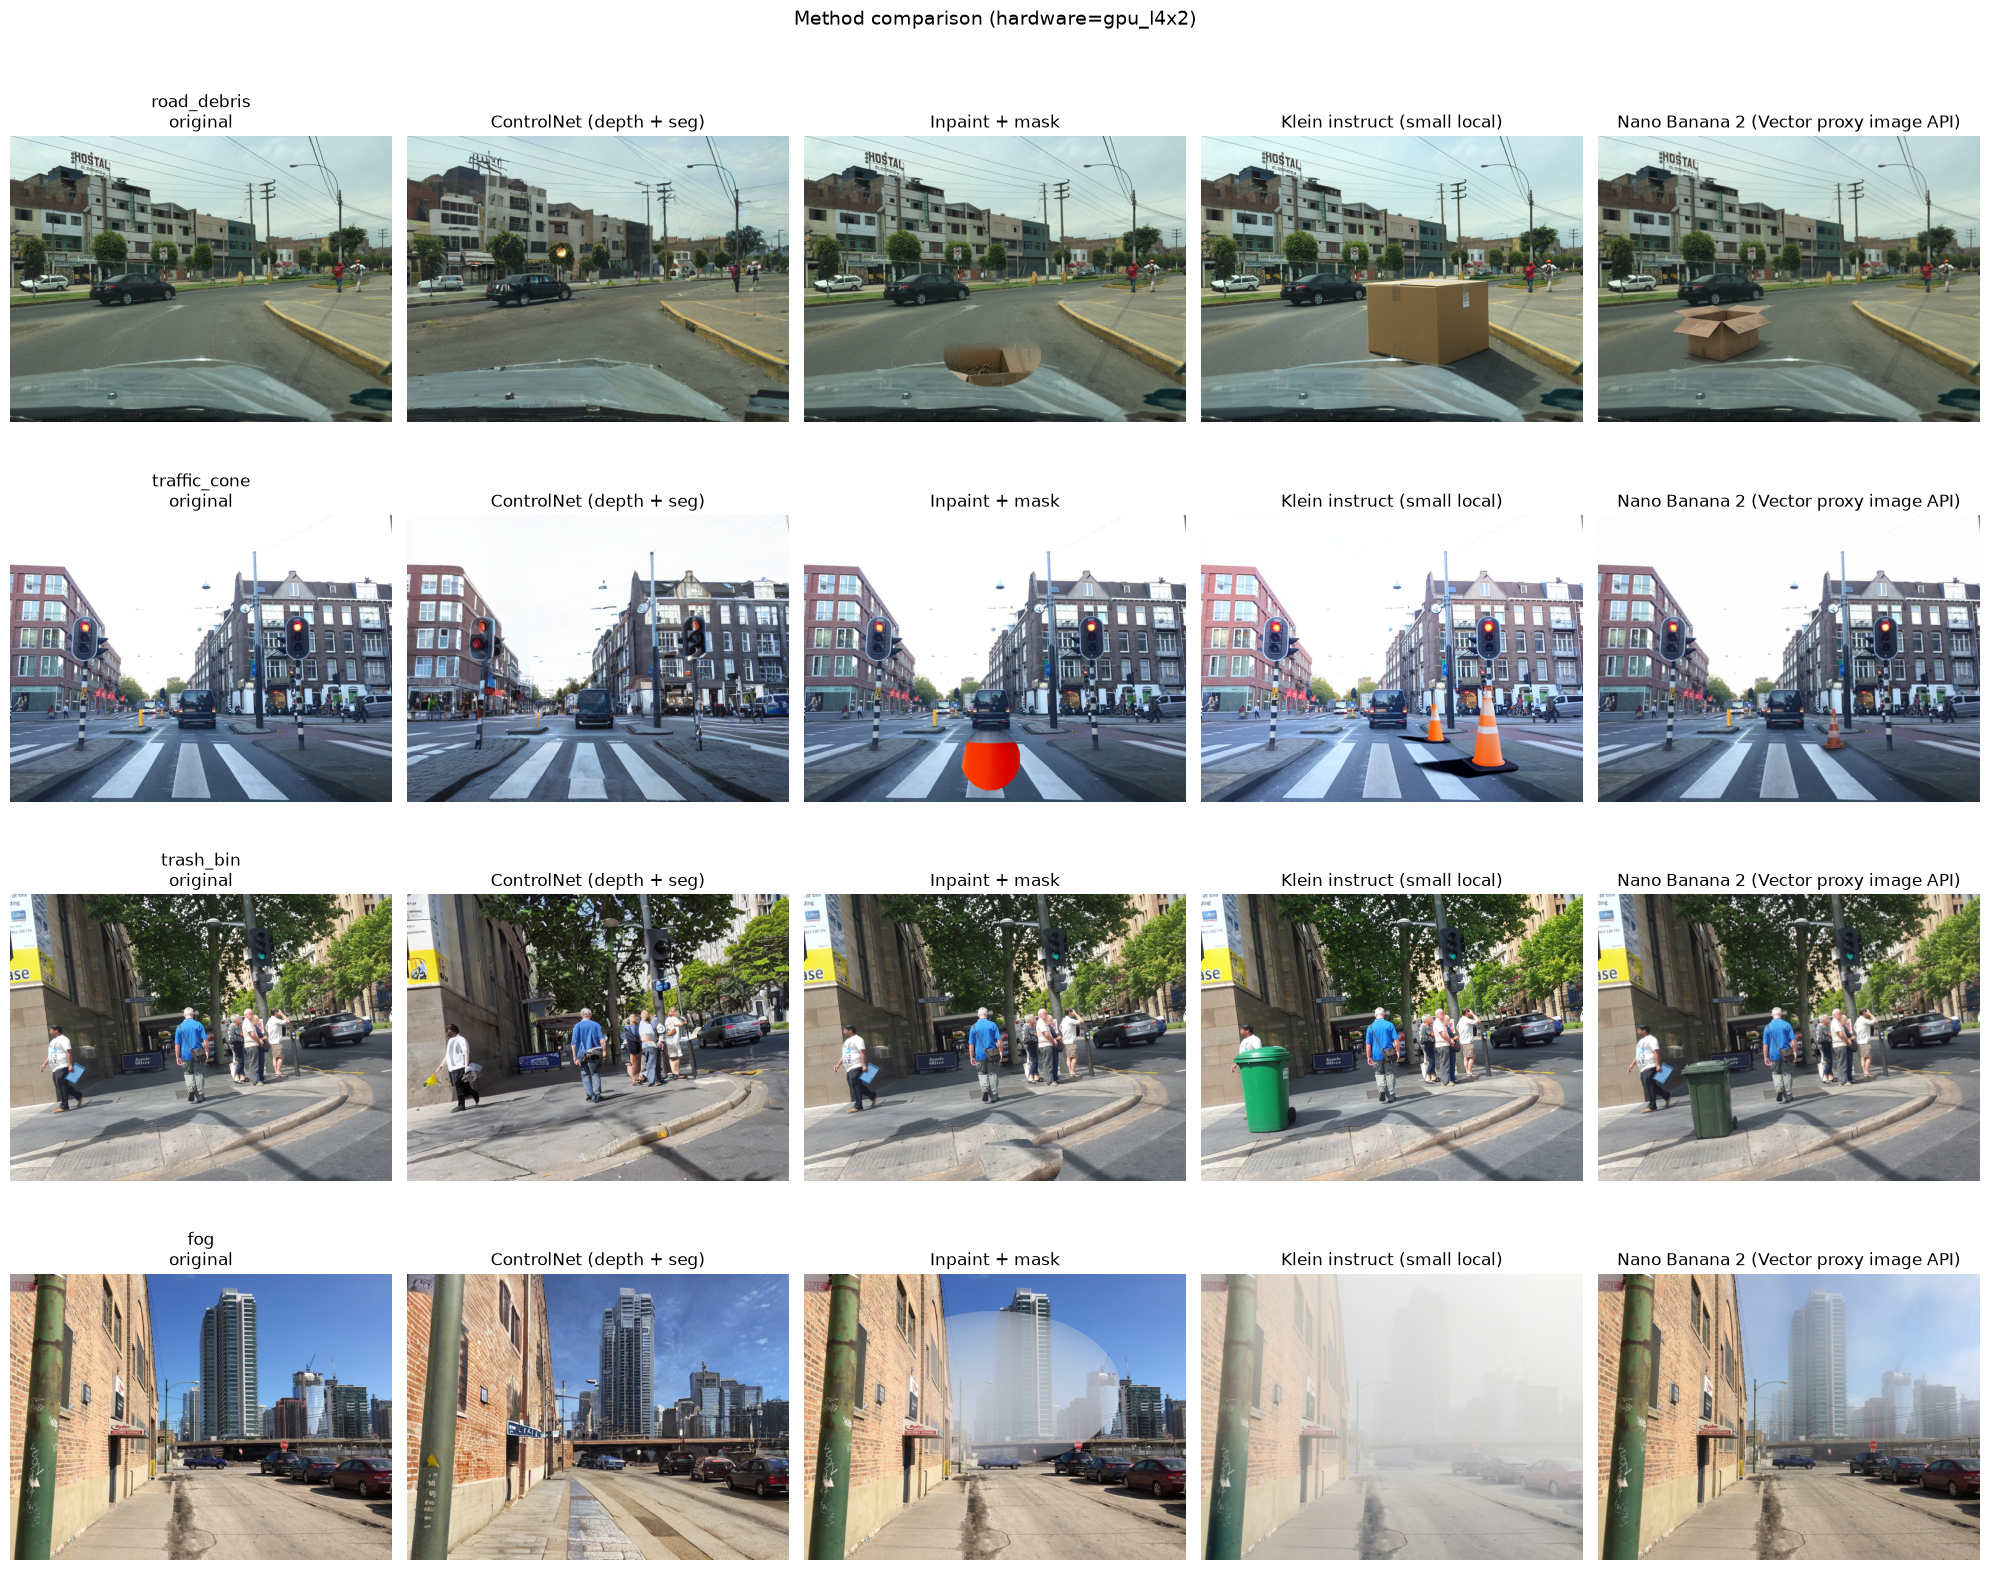

Saved /home/coder/synthetic-data-bootcamp/implementations/edge_case_image_generation/outputs/mapillary_vistas/compare/summary_gpu_l4x2.png


In [6]:
import matplotlib.pyplot as plt
from aieng.syn_data.image.compare_methods import METHOD_SPECS
from aieng.syn_data.image.viz import show_image


n_methods = len(ACTIVE_METHODS)
fig, axes = plt.subplots(len(bundles), 1 + n_methods, figsize=(4 * (1 + n_methods), 4 * len(bundles)))
if len(bundles) == 1:
    axes = axes.reshape(1, -1)

for row, (sample, bundle) in enumerate(bundles):
    show_image(sample.image, title=f"{bundle.anomaly_id}\noriginal", ax=axes[row, 0])
    for col, method in enumerate(ACTIVE_METHODS, start=1):
        show_image(
            bundle.results[method].image,
            title=METHOD_SPECS[method].title,
            ax=axes[row, col],
        )

fig.suptitle(f"Method comparison (hardware={HARDWARE})", fontsize=14, y=1.01)
plt.tight_layout()
out = Path(cfg.paths.outputs_dir) / "compare" / f"summary_{HARDWARE}.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=140, bbox_inches="tight")
plt.show()
print("Saved", out)

---
## 6. How to read the results

Discuss (or journal) with these prompts:

1. **Spatial control** — Which method put the object *on the road* where you wanted?
2. **Scene preservation** — Which kept cars / sky / lane markings intact?
3. **Mask cost** — Is authoring / deriving a mask worth the localization win?
4. **ControlNet** — Did depth+seg stop drift, or still rewrite too much?
5. **Klein instruct** — Followed the ask, or hood-paste / ignore / restyle?
6. **Cloud image model** *(if on)* — Closer seed fidelity, or stronger semantics with more rewrite?

### Rule of thumb for this bootcamp

| Goal | Start with |
|------|------------|
| Local insert (cone, debris on asphalt) | **Inpaint + mask**, or **Klein** if you accept weaker placement |
| Global atmosphere (fog) while keeping layout | **ControlNet** or **instruct** |
| Maximum semantics, cloud OK | **Nano Banana 2** column |
| **Default for NB1/NB2** | **`instruct` (Klein on L4)** — simple inputs, fast enough, good workshop tradeoff |

> **A visually impressive edit is not necessarily a useful training example.** It can drift from the real camera/scene style (fidelity), repeat what the dataset already has (novelty), or lack a clean, correctly placed box (usability). Notebooks 1–2 filter every edit on those signals, and Notebook 3 checks whether the survivors actually help a detector on real held-out photos.


---
## Wrap-up

- Set `METHOD_BY_ANOMALY` in [Notebook 1](01_sample_data_generation.ipynb) from what you saw (usually all `instruct`).
- **Judge** stays the Vector API vision model in `configs/default/judge.yaml` — separate from any image-edit column here.

### References

Footnotes point at [docs/citations.md](../docs/citations.md): latent diffusion [[1]], ControlNet [[2]], InstructPix2Pix [[3]], FLUX/Klein [[4]], Qwen-Image-Edit [[5]].
